In [1]:
%pip install -q otter-grader

Note: you may need to restart the kernel to use updated packages.


# In-Class Exercise 07: Generalization — Why Training Error Lies

**DS701 — Session 8 (Wed Sep 30, 2026) — Section A1**

[![](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tools4ds/DS701-Materials-FA26/blob/main/class_activity_notebooks/07-InClass-Exercise-Generalization-A1/07-InClass-Exercise-Generalization-A1.ipynb)

**Time: ~60 minutes.** Work in groups of 2-3.

Parts marked **(autograded)** are submitted to Gradescope; open-ended parts are graded
for participation. You may use AI assistance, but you must be able to explain and
justify every part of your solution when asked.

**Plan**

| Part | Topic | Grading | Time |
|---|---|---|---|
| 1 | Train/test discipline: the train-vs-test error curve, pick the degree | autograded | ~12 min |
| 2 | Pick the degree again with 5-fold cross-validation — without touching the test set | autograded | ~10 min |
| 3 | Bias-variance sanity check: degree 1 vs degree 9, refit on many samples | autograded | ~8 min |
| 4 | **Stretch** — learning curves: error vs training-set *size* for an under-fit and an over-fit model | autograded | ~15 min |
| 5 | **Stretch** — diagnose a mystery model from its learning curve alone | autograded | ~8 min |
| 6 | Prescribe the remedy, and design a protocol | participation | ~7 min |

Dependencies: `numpy`, `matplotlib`, `scikit-learn`.

## Setup

The lecture's toy problem, made yours. The data-generating process is a
polynomial plus Gaussian noise, fixed by the seed below. As in the lecture, we know the generator, so we can draw as much fresh
data as we like: that is what lets us *measure* generalization instead of guessing.

Three helpers are defined for you and used throughout — use them, do not re-implement:

- `make_dataset(n, seed)` — `n` equally spaced $x$ in $[-1, 1]$ and $y = f_{\text{true}}(x) + \varepsilon$, $\varepsilon \sim \mathcal N(0, \sigma^2)$;
- `fit_poly(x, y, degree)` — least-squares polynomial fit (a callable: `p(x_new)` predicts);
- `mse(y, y_hat)` — mean squared error.

The **training set** has only `N_TRAIN = 16` points, the **test set** 100. The test set is
the "future": in Part 1 we peek at it deliberately, to draw the lecture's plot; from Part 2
on it stays untouched until the very end.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import warnings

from numpy.polynomial import Polynomial
from sklearn.model_selection import KFold

warnings.filterwarnings("ignore")   # high-degree fits raise harmless RankWarnings

In [3]:
# Lecture section. Only A1 runs this semester; this is kept because the build
# script reads it to name the variant directory the notebook is published in.
SECTION = "A1"
SEED = 701
rng = np.random.default_rng(SEED)

In [4]:
# Colab: fetch the autograder tests for this activity.
import os, sys, urllib.request

if "google.colab" in sys.modules:
    os.makedirs("tests", exist_ok=True)
    BASE = "https://raw.githubusercontent.com/tools4ds/DS701-Materials-FA26/main/class_activity_notebooks/07-InClass-Exercise-Generalization-A1/tests/"
    for _q in ("q1", "q2", "q3", "q4", "q5"):
        urllib.request.urlretrieve(BASE + _q + ".py", "tests/" + _q + ".py")

In [5]:
# Initialize Otter
import otter
grader = otter.Notebook()

Section A1: true degree = 3, noise sd = 0.3 (noise variance = 0.090)
training set: 16 points, test set: 100 points


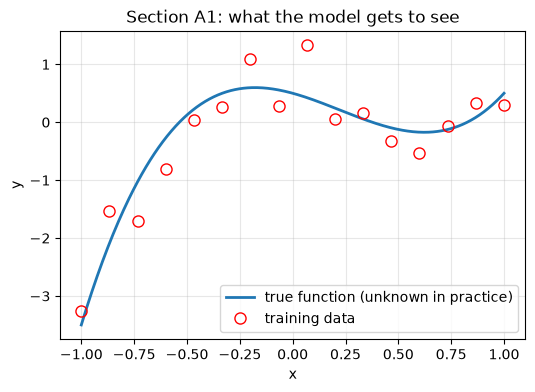

In [6]:
# --- The data-generating process for THIS section (do not edit) -----------------
# True function: a polynomial whose degree differs by section; noise level too.
TRUE_COEF = np.array([0.5, -1.0, -2.0, 3.0])  # quartic: 0.5 + 0.5x - 5x^2 + 4x^4
NOISE_SD = 0.30                  # sigma of the additive Gaussian noise
DATA_SEED = 708                   # seed of this section's train/test draw
TRUE_DEGREE = len(TRUE_COEF) - 1

N_TRAIN, N_TEST = 16, 100
DEGREES = np.arange(0, 13)          # candidate model complexities: 0, 1, ..., 12


def f_true(x):
    """The noiseless truth."""
    return Polynomial(TRUE_COEF)(x)


def make_dataset(n, seed):
    """n equally spaced x in [-1, 1]; y = f_true(x) + N(0, NOISE_SD^2) noise drawn with `seed`."""
    r = np.random.default_rng(seed)
    x = np.linspace(-1.0, 1.0, n)
    y = f_true(x) + r.normal(0.0, NOISE_SD, n)
    return x, y


def fit_poly(x, y, degree):
    """Least-squares polynomial of the given degree. Returns a callable p with p(x_new) -> predictions."""
    return Polynomial.fit(x, y, degree)


def mse(y, y_hat):
    """Mean squared error between targets y and predictions y_hat."""
    return float(np.mean((np.asarray(y) - np.asarray(y_hat)) ** 2))


x_train, y_train = make_dataset(N_TRAIN, DATA_SEED)
x_test, y_test = make_dataset(N_TEST, DATA_SEED + 1)

print(f"Section {SECTION}: true degree = {TRUE_DEGREE}, noise sd = {NOISE_SD} (noise variance = {NOISE_SD**2:.3f})")
print(f"training set: {len(x_train)} points, test set: {len(x_test)} points")

x_grid = np.linspace(-1, 1, 400)
plt.figure(figsize=(6, 4))
plt.plot(x_grid, f_true(x_grid), lw=2, label="true function (unknown in practice)")
plt.plot(x_train, y_train, "ro", mfc="none", ms=8, label="training data")
plt.xlabel("x"); plt.ylabel("y"); plt.legend(); plt.grid(alpha=0.3)
plt.title(f"Section {SECTION}: what the model gets to see")
plt.show()

## Part 1 (autograded): training error lies — the train-vs-test curve

The lecture's money plot: as the polynomial degree grows, training error falls
monotonically while test error falls, bottoms out, then rises. Reproduce it on *your*
data.

**Task.** For every degree $k$ in `DEGREES`, fit `fit_poly(x_train, y_train, k)` and record

1. `train_mse` — a NumPy array of length `len(DEGREES)`: the MSE of that fit on the **training** points;
2. `test_mse` — same shape: the MSE of the *same* fit on the **test** points;
3. `best_degree` — an `int`: the degree with the smallest **test** MSE.

Then run the plotting cell that follows and *look* before moving on.

In [ ]:
train_mse = np.array([mse(y_train, fit_poly(x_train, y_train, d)(x_train)) for d in DEGREES]) # Training MSE for each degree
test_mse = np.array([mse(y_test, fit_poly(x_train, y_train, d)(x_test)) for d in DEGREES]) # Test MSE for each degree
best_degree = DEGREES[np.argmin(test_mse)] # Best degree according to test MSE

print("degree :", " ".join(f"{k:6d}" for k in DEGREES))
print("train  :", " ".join(f"{v:6.3f}" for v in train_mse))
print("test   :", " ".join(f"{v:6.3f}" for v in test_mse))
print("best degree by TEST error:", best_degree, "   (true degree:", TRUE_DEGREE, ")")

degree :      0      1      2      3      4      5      6      7      8      9     10     11     12
train  :  1.192  0.794  0.345  0.157  0.130  0.127  0.088  0.086  0.075  0.066  0.064  0.063  0.063
test   :  0.988  0.708  0.326  0.117  0.130  0.132  0.176  0.184  0.205  0.230  0.251  0.272  0.248
best degree by TEST error: 3    (true degree: 3 )


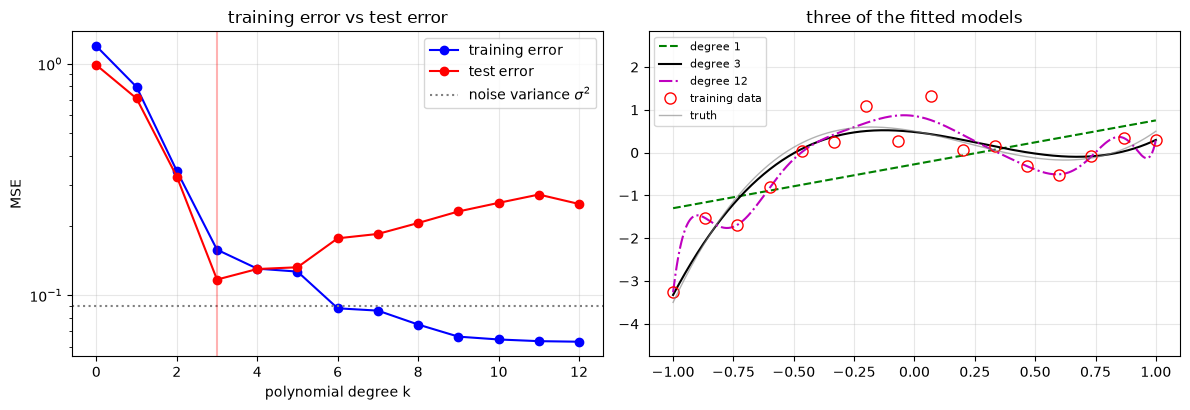

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].plot(DEGREES, train_mse, "bo-", label="training error")
axes[0].plot(DEGREES, test_mse, "ro-", label="test error")
axes[0].axhline(NOISE_SD**2, color="gray", ls=":", label=r"noise variance $\sigma^2$")
axes[0].axvline(best_degree, color="red", alpha=0.3)
axes[0].set_xlabel("polynomial degree k"); axes[0].set_ylabel("MSE"); axes[0].set_yscale("log")
axes[0].set_title("training error vs test error"); axes[0].legend(); axes[0].grid(alpha=0.3)

for k, style in ((1, "g--"), (best_degree, "k-"), (12, "m-.")):
    axes[1].plot(x_grid, fit_poly(x_train, y_train, k)(x_grid), style, label=f"degree {k}")
axes[1].plot(x_train, y_train, "ro", mfc="none", ms=8, label="training data")
axes[1].plot(x_grid, f_true(x_grid), color="gray", lw=1, alpha=0.6, label="truth")
axes[1].set_ylim(np.min(y_train) - 1.5, np.max(y_train) + 1.5)
axes[1].set_title("three of the fitted models"); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Discuss (participation):** the degree-12 model has the *lowest* training error of all
thirteen. Say in one sentence why that is exactly what the lecture means by "training
error lies", and point at the number in `test_mse` that proves it. Where does the test
curve bottom out relative to the dotted $\sigma^2$ line, and why can no model beat that line?

*the dotted line represents the irreducible error (the variance of the noise in the data), so no model can beat it because the noise is random and cannot be predicted from the input xxx. Even the true underlying function would still suffer an average error of σ2\sigma^2σ2 due to that unavoidable randomness.*

In [12]:
grader.check("q1")

q1 results: All test cases passed!

## Part 2 (autograded): choose the degree honestly — 5-fold cross-validation

In Part 1 we chose `best_degree` by looking at the **test** set. That breaks the
supervised contract: once the test set has influenced a decision, its error is no longer
an honest estimate of future performance. The lecture's fix is to choose hyperparameters
on **held-out training data** — here, with $K$-fold cross-validation — and touch the test
set only once, at the end.

`KFold(n_splits=5, shuffle=True, random_state=SEED)` partitions the 16 training points
into 5 folds; each fold plays validation set once while the other four train.

**Task.**

1. Write `cv_mse_for_degree(x, y, degree, kf)`: for each `(train_idx, val_idx)` in
   `kf.split(x)`, fit `fit_poly` on the training fold and score `mse` on the validation
   fold; return the **mean** validation MSE over the folds as a `float`.
2. `cv_mse` — array of length `len(DEGREES)`: the CV estimate for every degree, using
   `kf` defined below and **only** `x_train, y_train`.
3. `cv_degree` — `int`: the degree with the smallest CV error.
4. `test_mse_at_cv_degree` — `float`: *now* look at the test set once, and read off
   `test_mse[cv_degree]` from Part 1.

degree :        0        1        2        3        4        5        6        7        8        9       10       11       12
CV MSE :    1.489    1.148    0.587    0.236    0.390    1.021    0.620    3.019    7.591   14.218   10.902 2348.151 89208.480
degree chosen by 5-fold CV: 3   (Part 1's test-set pick: 3)
test MSE at the CV-chosen degree: 0.117   (minimum test MSE anywhere: 0.117)


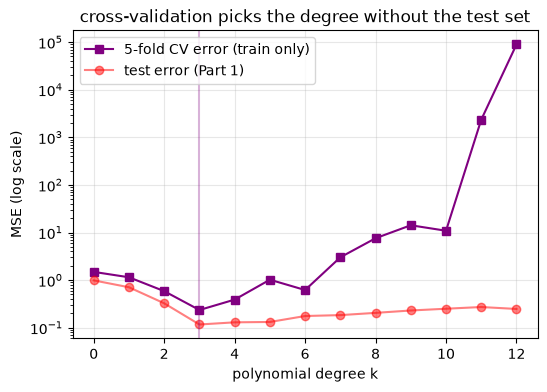

In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)


def cv_mse_for_degree(x, y, degree, kf):
    """Mean validation MSE of a degree-`degree` polynomial over the folds of `kf`."""
    mse_values = [] # Empty list to store MSE values for each fold
    for train_index, val_index in kf.split(x):
        x_train, x_val = x[train_index], x[val_index] # Split the data into training and validation sets for this fold
        y_train, y_val = y[train_index], y[val_index] # Split the data into training and validation sets for this fold
        # Fit the polynomial of the given degree on the training set and compute the MSE on the validation set
        mse_values.append(mse(y_val, fit_poly(x_train, y_train, degree)(x_val)))
    return np.mean(mse_values)

cv_mse = np.array([cv_mse_for_degree(x_train, y_train, d, kf) for d in DEGREES]) # Compute the cross-validation MSE for each degree
cv_degree = DEGREES[np.argmin(cv_mse)] # Degree that minimizes the cross-validation MSE
test_mse_at_cv_degree = test_mse[np.argmin(cv_mse)] # Test MSE at the degree chosen by cross-validation

print("degree :", " ".join(f"{k:8d}" for k in DEGREES))
print("CV MSE :", " ".join(f"{v:8.3f}" for v in cv_mse))
print(f"degree chosen by 5-fold CV: {cv_degree}   (Part 1's test-set pick: {best_degree})")
print(f"test MSE at the CV-chosen degree: {test_mse_at_cv_degree:.3f}   (minimum test MSE anywhere: {test_mse.min():.3f})")

plt.figure(figsize=(6, 4))
plt.plot(DEGREES, cv_mse, "s-", color="purple", label="5-fold CV error (train only)")
plt.plot(DEGREES, test_mse, "ro-", alpha=0.5, label="test error (Part 1)")
plt.axvline(cv_degree, color="purple", alpha=0.3)
plt.yscale("log"); plt.xlabel("polynomial degree k"); plt.ylabel("MSE (log scale)")
plt.legend(); plt.grid(alpha=0.3); plt.title("cross-validation picks the degree without the test set")
plt.show()

**Discuss (participation):**

1. Did CV pick the same degree as the test set did in Part 1? Either way, say why the
   two curves are allowed to disagree, and which of the two picks you are allowed to
   *report* as the model's expected error — and why the other one is optimistic.
2. The CV curve explodes at high degrees where the test curve merely drifts up. What
   about a 5-fold split of 16 points explains that? (How many points train each fold?
   How many parameters does a degree-12 polynomial have?)

*Picked same degree as the test set did with degree = 3. They are allowed to disagree because they are evaluating on different test sets. The first uses the test set so we are not allowed to report that one. The cv is trained with 13 parameters when using 12 degrees so it shoots up because it is extremely sensitive of the data points in the fold.*

In [15]:
grader.check("q2")

q2 results: All test cases passed!

## Part 3 (autograded): bias-variance sanity check — the lecture's $k = 1$ vs $k = 9$

The lecture called bias and variance "the two ways to be wrong": bias is the error of a
model too simple to capture the pattern; variance is how much the fitted model *changes*
when you refit it on a different sample from the same distribution. Both are defined
over **repeated draws of the training set**, which we can actually do here.

**Task.** For each `degree` in `(1, 9)`:

- draw `N_REPEATS = 50` fresh training sets `make_dataset(N_TRAIN, DATA_SEED + 100 + r)` for `r = 0, 1, ..., 49`;
- fit `fit_poly` to each and predict on `x_grid` — collect a `(50, len(x_grid))` array `preds`;
- `bias2[degree]` = the mean over the grid of $\big(\overline{\hat f}(x) - f_{\text{true}}(x)\big)^2$, where $\overline{\hat f}$ is the average prediction over the 50 fits (`preds.mean(axis=0)`);
- `variance[degree]` = the mean over the grid of the variance of the 50 predictions at each $x$ (`preds.var(axis=0)`).

Store the results in the two dicts `bias2` and `variance` (keys `1` and `9`, values `float`).
The plotting cell afterwards draws all 50 fits per degree — the "spaghetti" *is* variance.

In [ ]:
N_REPEATS = 50
bias2, variance = {}, {}
all_preds = {}   # kept for the plot below

for degree in (1, 9):
    ...
    all_preds[degree] = preds

for degree in (1, 9):
    print(f"degree {degree}:  bias^2 = {bias2[degree]:.4f}   variance = {variance[degree]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, degree in zip(axes, (1, 9)):
    for row in all_preds[degree]:
        ax.plot(x_grid, row, color="steelblue", alpha=0.15, lw=1)
    ax.plot(x_grid, all_preds[degree].mean(axis=0), "b-", lw=2, label="average fit")
    ax.plot(x_grid, f_true(x_grid), "k--", lw=2, label="truth")
    ax.set_ylim(np.min(y_train) - 2, np.max(y_train) + 2)
    ax.set_title(f"degree {degree}: 50 refits on fresh samples"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [ ]:
grader.check("q3")

Keep the two numbers in mind for what follows: the straight line has large bias and small
variance (every refit is nearly the same wrong line); the degree-9 model has almost no
bias but its refits scatter wildly. Model selection is the search for the degree in
between — and in Parts 4-5 we learn to *see* which of the two problems a model has
without knowing the truth.

## Part 4 (stretch): learning curves — error as a function of training-set *size*

Everything so far varied the **model** at fixed data. A **learning curve** holds the
model fixed and varies the **amount of training data**, plotting training error and
validation error against $n$. The lecture never drew one — but it is the diagnostic that
tells you, on a real project, whether collecting more data would help. Two signatures
to learn:

- **high bias** (under-fit): training and validation error converge quickly to a common
  level — and that level is *high* (well above the noise floor). More data does not help;
  the model cannot represent the pattern.
- **high variance** (over-fit): training error is tiny, validation error is large, and
  the **gap** between them narrows only as $n$ grows. More data *does* help — and so
  would a simpler model.

Here we know the noise floor: no model can beat $\sigma^2 = $ `NOISE_SD**2` on average.

### 4a (autograded): learning curves for degree 1 and degree 12

**Task.** Complete `learning_curve(degree)`: for each `n` in `N_GRID`, and for each of
`N_LC_REPEATS = 5` repeats `r = 0, ..., 4`, draw a fresh training set of size `n` with
`make_dataset(n, DATA_SEED + 1000 * (r + 1) + n)`, fit `fit_poly`, and record its MSE on
that training set and on the fixed validation set `x_val, y_val` (500 points, drawn
below). Average the 5 repeats and return two arrays of length `len(N_GRID)`:
`(train_curve, val_curve)`.

Then build the dicts `lc_train = {1: ..., 12: ...}` and `lc_val = {1: ..., 12: ...}`.

In [ ]:
N_GRID = np.array([10, 15, 20, 30, 40, 60, 80, 100, 140, 200])
N_LC_REPEATS = 5
x_val, y_val = make_dataset(500, DATA_SEED + 2)     # a large held-out validation set


def learning_curve(degree):
    """(train_curve, val_curve): mean MSE over N_LC_REPEATS fresh training sets, for each n in N_GRID."""
    train_curve, val_curve = [], []
    for n in N_GRID:
        ...
    return np.array(train_curve), np.array(val_curve)


lc_train, lc_val = {}, {}
for degree in (1, 12):
    lc_train[degree], lc_val[degree] = ...

print("n         :", " ".join(f"{n:7d}" for n in N_GRID))
for degree in (1, 12):
    print(f"deg {degree:2d} train:", " ".join(f"{v:7.3f}" for v in lc_train[degree]))
    print(f"deg {degree:2d} val  :", " ".join(f"{v:7.3f}" for v in lc_val[degree]))
print(f"noise floor sigma^2 = {NOISE_SD**2:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
for ax, degree in zip(axes, (1, 12)):
    ax.plot(N_GRID, lc_train[degree], "bo-", label="training error")
    ax.plot(N_GRID, lc_val[degree], "ro-", label="validation error")
    ax.axhline(NOISE_SD**2, color="gray", ls=":", label=r"noise floor $\sigma^2$")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("training-set size n"); ax.set_title(f"learning curve, degree {degree}")
    ax.legend(); ax.grid(alpha=0.3, which="both")
axes[0].set_ylabel("MSE")
plt.tight_layout(); plt.show()

**Discuss (participation):** read the two signatures off your plot.

1. Degree 1: where do the two curves converge relative to the dotted $\sigma^2$ line?
   Would collecting 10× more data fix this model? What would?
2. Degree 12: at $n = 200$ its validation error is nearly at $\sigma^2$ and its training
   error has *risen* to meet it. Why does the *training* error of a fixed model go **up**
   as $n$ grows? Which two remedies for over-fitting from the lecture does this curve
   demonstrate?

*(2-3 sentences here)*

In [ ]:
grader.check("q4")

## Part 5 (stretch, autograded): diagnose a mystery model from its learning curve

A colleague hands you the learning curve of a model you know nothing about — not the
model, not the noise level, not the true function. Just two arrays over training-set
sizes `MYSTERY_N`. Your section's mystery differs from the other section's.

**Task.**

1. `mystery_gap` — array: validation minus training error at each size.
2. `mystery_val_drop` — `float`: how much the validation error fell from the smallest to the largest $n$.
3. `diagnosis` — exactly one of the strings `"high bias"` or `"high variance"`.
4. `more_data_helps` — `bool`: would collecting more training data substantially reduce
   this model's validation error, judging from the curve?

Plot the curve first (cell provided) — then decide from the *shape*, not from a hunch.

In [ ]:
MYSTERY_N = np.array([25, 30, 40, 60, 80, 100, 140, 200])
MYSTERY_TRAIN = np.array([0.0765, 0.0964, 0.1432, 0.1980, 0.2057, 0.2442, 0.2195, 0.2520])
MYSTERY_VAL = np.array([0.7470, 0.4800, 0.3735, 0.3146, 0.2794, 0.2970, 0.2775, 0.2751])

plt.figure(figsize=(6, 4))
plt.plot(MYSTERY_N, MYSTERY_TRAIN, "bo-", label="training error")
plt.plot(MYSTERY_N, MYSTERY_VAL, "ro-", label="validation error")
plt.xscale("log"); plt.xlabel("training-set size n"); plt.ylabel("MSE")
plt.title(f"the mystery model's learning curve (section {SECTION})"); plt.legend(); plt.grid(alpha=0.3, which="both")
plt.show()

...

print("gap (val - train):", np.round(mystery_gap, 3))
print(f"validation error dropped by {mystery_val_drop:.3f} from n={MYSTERY_N[0]} to n={MYSTERY_N[-1]}")
print("diagnosis:", diagnosis, "| more data helps:", more_data_helps)

In [ ]:
grader.check("q5")

<!-- BEGIN QUESTION -->

## Part 6 (participation): prescribe the remedy — and design a protocol

Write your group's answers, citing numbers from your notebook:

1. **Prescription for the mystery model.** Choose among *more data*, *a simpler model*,
   *a more flexible model / more features* — one or two of these — and justify from the
   shape of the curve: what did the gap do, what did the validation error do, and what
   would each of the three remedies do to this particular curve?
2. **Where is the floor?** For your degree-1 and degree-12 learning curves, say where
   each converged relative to $\sigma^2$ and what that tells you about which "way of being
   wrong" each model has. On a real dataset you do not know $\sigma^2$ — what can you still
   read off a learning curve without it?
3. **Protocol.** In Part 1 we chose the degree with the test set; in Part 2 with CV. Write
   the three-step protocol you would follow on a real project — data with $N$ rows, one
   hyperparameter to choose, one number to report — so that the reported number is
   honest. Say what would happen to your reported number if you skipped the split.

> Staff will visit tables during this part. Be ready to explain your reasoning and to
> point at the cell that supports each claim.

_Type your answer here, replacing this text._

<!-- END QUESTION -->

## Wrap-up

Before you leave, each group should be able to answer, without notes:

1. Why can training error only go down as model complexity goes up, and what curve do
   you draw instead to choose a model?
2. What is the one rule about the test set, and how did $K$-fold CV let you choose the
   degree without breaking it?
3. Show me a learning curve that says "collect more data" and one that says "don't
   bother" — what feature of the picture is the difference?

Submit the autograded parts (1–5) to Gradescope.